# 07 - Simple linear regression baseline PLR

This notebook estimates baseline module-level performance loss rates using simple linear regression.

The main input is the monthly \(PR_\mathrm{DC,25C}\) dataset prepared in Notebook 05. The g200 dataset is treated as the main SLR baseline, while g400 and sunny are retained as irradiance-filtering sensitivity datasets.

The main outputs are:

1. SLR PLR estimates for each module
2. fitted monthly SLR trends for the main g200 dataset
3. module-level SLR PLR estimates with 95% confidence intervals
4. optional irradiance-filtering sensitivity figure

## 1. Imports and plotting style

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,

    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "legend.fontsize": 12,
    "legend.title_fontsize": 12,

    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.7,
})

TITLE_SIZE = 16
SUBTITLE_SIZE = 14
AXIS_LABEL_SIZE = 12
LEGEND_SIZE = 12

## 2. Project paths

The notebook reads the monthly PLR input datasets from Notebook 05 and saves SLR result tables and figures to the final thesis output folders.

In [2]:
PROJECT_ROOT = Path("C:/Users/amina/Thesis/Final Pipeline")

DIRS = {
    "data_processed": PROJECT_ROOT / "data_processed",
    "figures": PROJECT_ROOT / "figures",
    "tables": PROJECT_ROOT / "tables",
}

PLR_INPUT_DIR = DIRS["data_processed"] / "plr_final_inputs"
SLR_OUTPUT_DIR = DIRS["data_processed"] / "slr_outputs"

FINAL_FIG_DIR = DIRS["figures"] / "final figures"
FINAL_TABLE_DIR = DIRS["tables"] / "final tables"

for folder in [SLR_OUTPUT_DIR, FINAL_FIG_DIR, FINAL_TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

MONTHLY_INPUT_PATHS = {
    "g200": PLR_INPUT_DIR / "g200_monthly_pr25c_filtered_for_plr.parquet",
    "g400": PLR_INPUT_DIR / "g400_monthly_pr25c_filtered_for_plr.parquet",
    "sunny": PLR_INPUT_DIR / "sunny_monthly_pr25c_filtered_for_plr.parquet",
}

DATASET_LABELS = {
    "g200": r"$G_\mathrm{POA} \geq 200$ W/m$^2$",
    "g400": r"$G_\mathrm{POA} \geq 400$ W/m$^2$",
    "sunny": "Sunny-day",
}

print("Project root:", PROJECT_ROOT)
print("PLR input folder:", PLR_INPUT_DIR)
print("SLR output folder:", SLR_OUTPUT_DIR)
print("Figure folder:", FINAL_FIG_DIR)
print("Table folder:", FINAL_TABLE_DIR)

for dataset_name, path in MONTHLY_INPUT_PATHS.items():
    print(f"{dataset_name} input exists:", path.exists(), "|", path)

Project root: C:\Users\amina\Thesis\Final Pipeline
PLR input folder: C:\Users\amina\Thesis\Final Pipeline\data_processed\plr_final_inputs
SLR output folder: C:\Users\amina\Thesis\Final Pipeline\data_processed\slr_outputs
Figure folder: C:\Users\amina\Thesis\Final Pipeline\figures\final figures
Table folder: C:\Users\amina\Thesis\Final Pipeline\tables\final tables
g200 input exists: True | C:\Users\amina\Thesis\Final Pipeline\data_processed\plr_final_inputs\g200_monthly_pr25c_filtered_for_plr.parquet
g400 input exists: True | C:\Users\amina\Thesis\Final Pipeline\data_processed\plr_final_inputs\g400_monthly_pr25c_filtered_for_plr.parquet
sunny input exists: True | C:\Users\amina\Thesis\Final Pipeline\data_processed\plr_final_inputs\sunny_monthly_pr25c_filtered_for_plr.parquet


## 3. Constants and module metadata

The main SLR metric is monthly temperature-corrected DC performance ratio, \(PR_\mathrm{DC,25C}\). PLR is reported in %/year.

In [3]:
MAIN_METRIC = "PR_25C"
TIME_COL = "Month_Start"

MIN_MONTHS_FOR_SLR = 12
DAYS_PER_YEAR = 365.25

CONFIDENCE_LEVEL = 0.95
ALPHA = 1 - CONFIDENCE_LEVEL

BLACK = "#222222"

TYPE_COLORS = {
    "Reference": "#009E73",
    "PID/Reference": "#0072B2",
    "uCrack": "#D55E00",
    "Unknown": "#7F7F7F",
}

module_meta = pd.DataFrame({
    "Module_ID": list(range(1, 11)),
    "Type": [
        "PID/Reference",
        "Reference",
        "uCrack",
        "uCrack",
        "Reference",
        "uCrack",
        "uCrack",
        "uCrack",
        "uCrack",
        "Reference",
    ],
})

MODULE_TYPE_MAP = dict(zip(module_meta["Module_ID"], module_meta["Type"]))

display(module_meta)

,Module_ID,Type
0,1,PID/Reference
1,2,Reference
2,3,uCrack
3,4,uCrack
4,5,Reference
5,6,uCrack
6,7,uCrack
7,8,uCrack
8,9,uCrack
9,10,Reference


## 4. Helper functions

In [5]:
def save_fig(filename, fig=None):
    """
    Save figure to the final figure directory.
    """
    if fig is None:
        fig = plt.gcf()

    out_path = FINAL_FIG_DIR / filename
    fig.savefig(out_path, bbox_inches="tight", dpi=300)
    print("Saved:", out_path)


def format_date_axis(ax):
    """
    Format x-axis for monthly time-series plots.
    """
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
    ax.tick_params(axis="x", rotation=0)


def get_type_color(module_type):
    """
    Return module-category colour.
    """
    return TYPE_COLORS.get(module_type, TYPE_COLORS["Unknown"])


def module_category_legend_handles(edgecolor=BLACK):
    """
    Legend handles for module categories.
    """
    return [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            markersize=7,
            markerfacecolor=TYPE_COLORS["Reference"],
            markeredgecolor=edgecolor,
            markeredgewidth=0.7,
            label="Reference",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            markersize=7,
            markerfacecolor=TYPE_COLORS["uCrack"],
            markeredgecolor=edgecolor,
            markeredgewidth=0.7,
            label="uCrack",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            markersize=7,
            markerfacecolor=TYPE_COLORS["PID/Reference"],
            markeredgecolor=edgecolor,
            markeredgewidth=0.7,
            label="PID/Reference",
        ),
    ]

## 5. Load monthly PLR input datasets

The monthly \(PR_\mathrm{DC,25C}\) datasets are loaded from Notebook 05. The g200 dataset is used as the main SLR baseline, while g400 and sunny are used for sensitivity checks.

In [6]:
monthly_datasets = {}

for dataset_name, path in MONTHLY_INPUT_PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing monthly input for {dataset_name}: {path}")

    df_temp = pd.read_parquet(path)

    if "Month_Start" in df_temp.columns:
        df_temp["Month_Start"] = pd.to_datetime(df_temp["Month_Start"])
    elif "YearMonth" in df_temp.columns:
        df_temp["Month_Start"] = pd.to_datetime(df_temp["YearMonth"])
    else:
        raise ValueError(f"{dataset_name}: missing Month_Start or YearMonth column.")

    if "YearMonth" not in df_temp.columns:
        df_temp["YearMonth"] = df_temp["Month_Start"].dt.to_period("M").astype(str)

    if "Type" not in df_temp.columns:
        df_temp = df_temp.merge(module_meta, on="Module_ID", how="left")

    df_temp["dataset"] = dataset_name
    df_temp["dataset_label"] = DATASET_LABELS[dataset_name]

    df_temp = df_temp.sort_values(["Module_ID", "Month_Start"]).reset_index(drop=True)

    required_cols = [
        "Module_ID",
        "Type",
        "Month_Start",
        "YearMonth",
        MAIN_METRIC,
        "n_days_month",
    ]

    missing_cols = [col for col in required_cols if col not in df_temp.columns]
    if missing_cols:
        raise ValueError(f"{dataset_name} is missing required columns: {missing_cols}")

    monthly_datasets[dataset_name] = df_temp

    print(f"{dataset_name} loaded")
    print("Shape:", df_temp.shape)
    print("Month range:", df_temp["Month_Start"].min(), "to", df_temp["Month_Start"].max())
    print("Modules:", sorted(df_temp["Module_ID"].unique()))
    print("-" * 80)

g200 loaded
Shape: (416, 36)
Month range: 2017-01-01 00:00:00 to 2021-10-01 00:00:00
Modules: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
--------------------------------------------------------------------------------
g400 loaded
Shape: (356, 36)
Month range: 2017-04-01 00:00:00 to 2021-10-01 00:00:00
Modules: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
--------------------------------------------------------------------------------
sunny loaded
Shape: (162, 36)
Month range: 2017-05-01 00:00:00 to 2021-09-01 00:00:00
Modules: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
--------------------------------------------------------------------------------


## 6. Prepare SLR modelling data

For each module, time is expressed in years since that module’s first valid monthly observation. The fitted model is:

\[
PR_\mathrm{DC,25C}(t) = \beta_0 + \beta_1t + \epsilon
\]

where \(t\) is time in years. The relative SLR PLR is calculated as:

\[
PLR_\mathrm{SLR} = 100 \times \frac{\beta_1}{\beta_0}
\]

Negative values indicate performance loss.

In [7]:
slr_model_datasets = {}

for dataset_name, df_temp in monthly_datasets.items():
    model_df = df_temp.dropna(
        subset=["Module_ID", "Month_Start", MAIN_METRIC]
    ).copy()

    model_df["module_start_month"] = (
        model_df.groupby("Module_ID")["Month_Start"]
        .transform("min")
    )

    model_df["time_days"] = (
        model_df["Month_Start"] - model_df["module_start_month"]
    ).dt.days

    model_df["time_years"] = model_df["time_days"] / DAYS_PER_YEAR

    model_df = model_df.sort_values(["Module_ID", "Month_Start"]).reset_index(drop=True)

    month_counts = model_df.groupby("Module_ID").size()

    if (month_counts < MIN_MONTHS_FOR_SLR).any():
        insufficient = month_counts.loc[month_counts < MIN_MONTHS_FOR_SLR]
        raise ValueError(
            f"{dataset_name}: modules with insufficient months for SLR:\n{insufficient}"
        )

    slr_model_datasets[dataset_name] = model_df

    print(f"{dataset_name} modelling dataset prepared")
    print("Shape:", model_df.shape)
    print("Minimum months per module:", month_counts.min())
    print("Maximum months per module:", month_counts.max())
    print("-" * 80)

g200 modelling dataset prepared
Shape: (416, 39)
Minimum months per module: 40
Maximum months per module: 43
--------------------------------------------------------------------------------
g400 modelling dataset prepared
Shape: (356, 39)
Minimum months per module: 30
Maximum months per module: 38
--------------------------------------------------------------------------------
sunny modelling dataset prepared
Shape: (162, 39)
Minimum months per module: 15
Maximum months per module: 17
--------------------------------------------------------------------------------


## 7. Fit SLR models

Simple linear regression is fitted separately for each module and each dataset. The fitted slope is converted into relative PLR using the fitted intercept.

In [8]:
def fit_slr_for_module(module_df):
    """
    Fit simple linear regression to one module's monthly PR_DC,25C time series.
    """
    module_df = module_df.sort_values("Month_Start").copy()

    module_id = int(module_df["Module_ID"].iloc[0])
    module_type = module_df["Type"].iloc[0]
    dataset_name = module_df["dataset"].iloc[0]
    dataset_label = module_df["dataset_label"].iloc[0]

    n_months = len(module_df)

    y = module_df[MAIN_METRIC].astype(float)
    X = sm.add_constant(module_df["time_years"].astype(float))

    model = sm.OLS(y, X).fit()

    beta_0 = model.params["const"]
    beta_1 = model.params["time_years"]

    beta_0_se = model.bse["const"]
    beta_1_se = model.bse["time_years"]

    beta_1_ci_low, beta_1_ci_high = model.conf_int(alpha=ALPHA).loc["time_years"]

    plr_pct_per_year = 100 * beta_1 / beta_0
    plr_ci_low_pct_per_year = 100 * beta_1_ci_low / beta_0
    plr_ci_high_pct_per_year = 100 * beta_1_ci_high / beta_0
    plr_se_pct_per_year = 100 * beta_1_se / beta_0

    pred = model.get_prediction(X)
    pred_summary = pred.summary_frame(alpha=ALPHA)

    prediction_df = module_df[
        [
            "dataset",
            "dataset_label",
            "Module_ID",
            "Type",
            "Month_Start",
            "YearMonth",
            "time_years",
            MAIN_METRIC,
            "n_days_month",
        ]
    ].copy()

    prediction_df["SLR_fit"] = pred_summary["mean"].to_numpy()
    prediction_df["SLR_fit_ci_lower"] = pred_summary["mean_ci_lower"].to_numpy()
    prediction_df["SLR_fit_ci_upper"] = pred_summary["mean_ci_upper"].to_numpy()

    result_row = {
        "dataset": dataset_name,
        "dataset_label": dataset_label,
        "Module_ID": module_id,
        "Type": module_type,

        "n_months": n_months,
        "first_month": module_df["Month_Start"].min(),
        "last_month": module_df["Month_Start"].max(),
        "time_span_years": module_df["time_years"].max() - module_df["time_years"].min(),

        "intercept_PR_25C": beta_0,
        "intercept_se": beta_0_se,

        "slope_abs_per_year": beta_1,
        "slope_abs_se": beta_1_se,
        "slope_abs_ci_low": beta_1_ci_low,
        "slope_abs_ci_high": beta_1_ci_high,

        "PLR_SLR_pct_per_year": plr_pct_per_year,
        "PLR_SLR_se_pct_per_year": plr_se_pct_per_year,
        "PLR_SLR_ci_low_pct_per_year": plr_ci_low_pct_per_year,
        "PLR_SLR_ci_high_pct_per_year": plr_ci_high_pct_per_year,

        "r_squared": model.rsquared,
        "adj_r_squared": model.rsquared_adj,
        "p_value_slope": model.pvalues["time_years"],
        "residual_std": np.sqrt(model.mse_resid),
        "aic": model.aic,
        "bic": model.bic,
    }

    return result_row, prediction_df

In [9]:
slr_result_rows = []
slr_prediction_tables = []

for dataset_name, model_df in slr_model_datasets.items():
    for module_id, module_df in model_df.groupby("Module_ID"):
        result_row, prediction_df = fit_slr_for_module(module_df)

        slr_result_rows.append(result_row)
        slr_prediction_tables.append(prediction_df)

slr_results = (
    pd.DataFrame(slr_result_rows)
    .sort_values(["dataset", "Module_ID"])
    .reset_index(drop=True)
)

slr_predictions = (
    pd.concat(slr_prediction_tables, ignore_index=True)
    .sort_values(["dataset", "Module_ID", "Month_Start"])
    .reset_index(drop=True)
)

slr_results_compact = slr_results[
    [
        "dataset",
        "Module_ID",
        "Type",
        "n_months",
        "time_span_years",
        "intercept_PR_25C",
        "slope_abs_per_year",
        "PLR_SLR_pct_per_year",
        "PLR_SLR_ci_low_pct_per_year",
        "PLR_SLR_ci_high_pct_per_year",
        "p_value_slope",
        "r_squared",
    ]
].copy()

slr_g200_results = (
    slr_results_compact
    .loc[slr_results_compact["dataset"] == "g200"]
    .sort_values("Module_ID")
    .reset_index(drop=True)
)

display(slr_g200_results)

,dataset,Module_ID,Type,n_months,time_span_years,intercept_PR_25C,slope_abs_per_year,PLR_SLR_pct_per_year,PLR_SLR_ci_low_pct_per_year,PLR_SLR_ci_high_pct_per_year,p_value_slope,r_squared
0,g200,1,PID/Reference,42,4.747433,0.983467,-0.003713,-0.377533,-0.599957,-0.155109,1.411620e-03,0.227326
1,g200,2,Reference,43,4.747433,0.979448,-0.002897,-0.295753,-0.553917,-0.037590,2.578061e-02,0.115478
2,g200,3,uCrack,42,4.747433,0.677919,0.000041,0.006091,-0.514413,0.526595,9.812493e-01,0.000014
3,g200,4,uCrack,43,4.747433,0.941470,-0.003439,-0.365315,-0.622260,-0.108371,6.440975e-03,0.167420
4,g200,5,Reference,42,4.747433,0.989415,-0.003112,-0.314549,-0.550049,-0.079049,1.012715e-02,0.154104
5,g200,6,uCrack,42,4.747433,0.953468,-0.003867,-0.405623,-0.672963,-0.138283,3.872821e-03,0.190338
6,g200,7,uCrack,41,4.747433,0.940311,-0.005847,-0.621814,-0.965986,-0.277641,7.577813e-04,0.255078
7,g200,8,uCrack,40,4.747433,0.946888,-0.008218,-0.867885,-1.177895,-0.557875,1.628079e-06,0.458065
8,g200,9,uCrack,41,4.665298,0.967581,-0.014057,-1.452835,-1.835944,-1.069725,2.619916e-09,0.601375
9,g200,10,Reference,40,4.665298,0.987932,-0.012715,-1.287079,-1.883847,-0.690310,9.395220e-05,0.334068


## 8. Save SLR result tables

The SLR results are saved as full and compact tables. Fitted monthly values are saved separately for plotting and later method comparison.

In [10]:
SLR_FULL_RESULTS_PATH = FINAL_TABLE_DIR / "slr_full_results_all_datasets.csv"
SLR_COMPACT_RESULTS_PATH = FINAL_TABLE_DIR / "slr_plr_summary_all_datasets.csv"
SLR_G200_RESULTS_PATH = FINAL_TABLE_DIR / "slr_plr_summary_g200_main_dataset.csv"
SLR_PREDICTIONS_PATH = SLR_OUTPUT_DIR / "slr_predictions_all_datasets.parquet"

slr_results.to_csv(SLR_FULL_RESULTS_PATH, index=False)
slr_results_compact.to_csv(SLR_COMPACT_RESULTS_PATH, index=False)
slr_g200_results.to_csv(SLR_G200_RESULTS_PATH, index=False)
slr_predictions.to_parquet(SLR_PREDICTIONS_PATH, index=False)

print("Saved SLR full results:", SLR_FULL_RESULTS_PATH)
print("Saved SLR compact results:", SLR_COMPACT_RESULTS_PATH)
print("Saved g200 SLR results:", SLR_G200_RESULTS_PATH)
print("Saved SLR predictions:", SLR_PREDICTIONS_PATH)

Saved SLR full results: C:\Users\amina\Thesis\Final Pipeline\tables\final tables\slr_full_results_all_datasets.csv
Saved SLR compact results: C:\Users\amina\Thesis\Final Pipeline\tables\final tables\slr_plr_summary_all_datasets.csv
Saved g200 SLR results: C:\Users\amina\Thesis\Final Pipeline\tables\final tables\slr_plr_summary_g200_main_dataset.csv
Saved SLR predictions: C:\Users\amina\Thesis\Final Pipeline\data_processed\slr_outputs\slr_predictions_all_datasets.parquet


## 9. Plot SLR trends for monthly PR_DC,25C

This figure shows the monthly \(PR_\mathrm{DC,25C}\) time series and fitted SLR trend for each module in the main g200 dataset. The shaded band represents the 95% confidence interval of the fitted mean trend.

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\slr_trends_monthly_prdc25c_g200.png


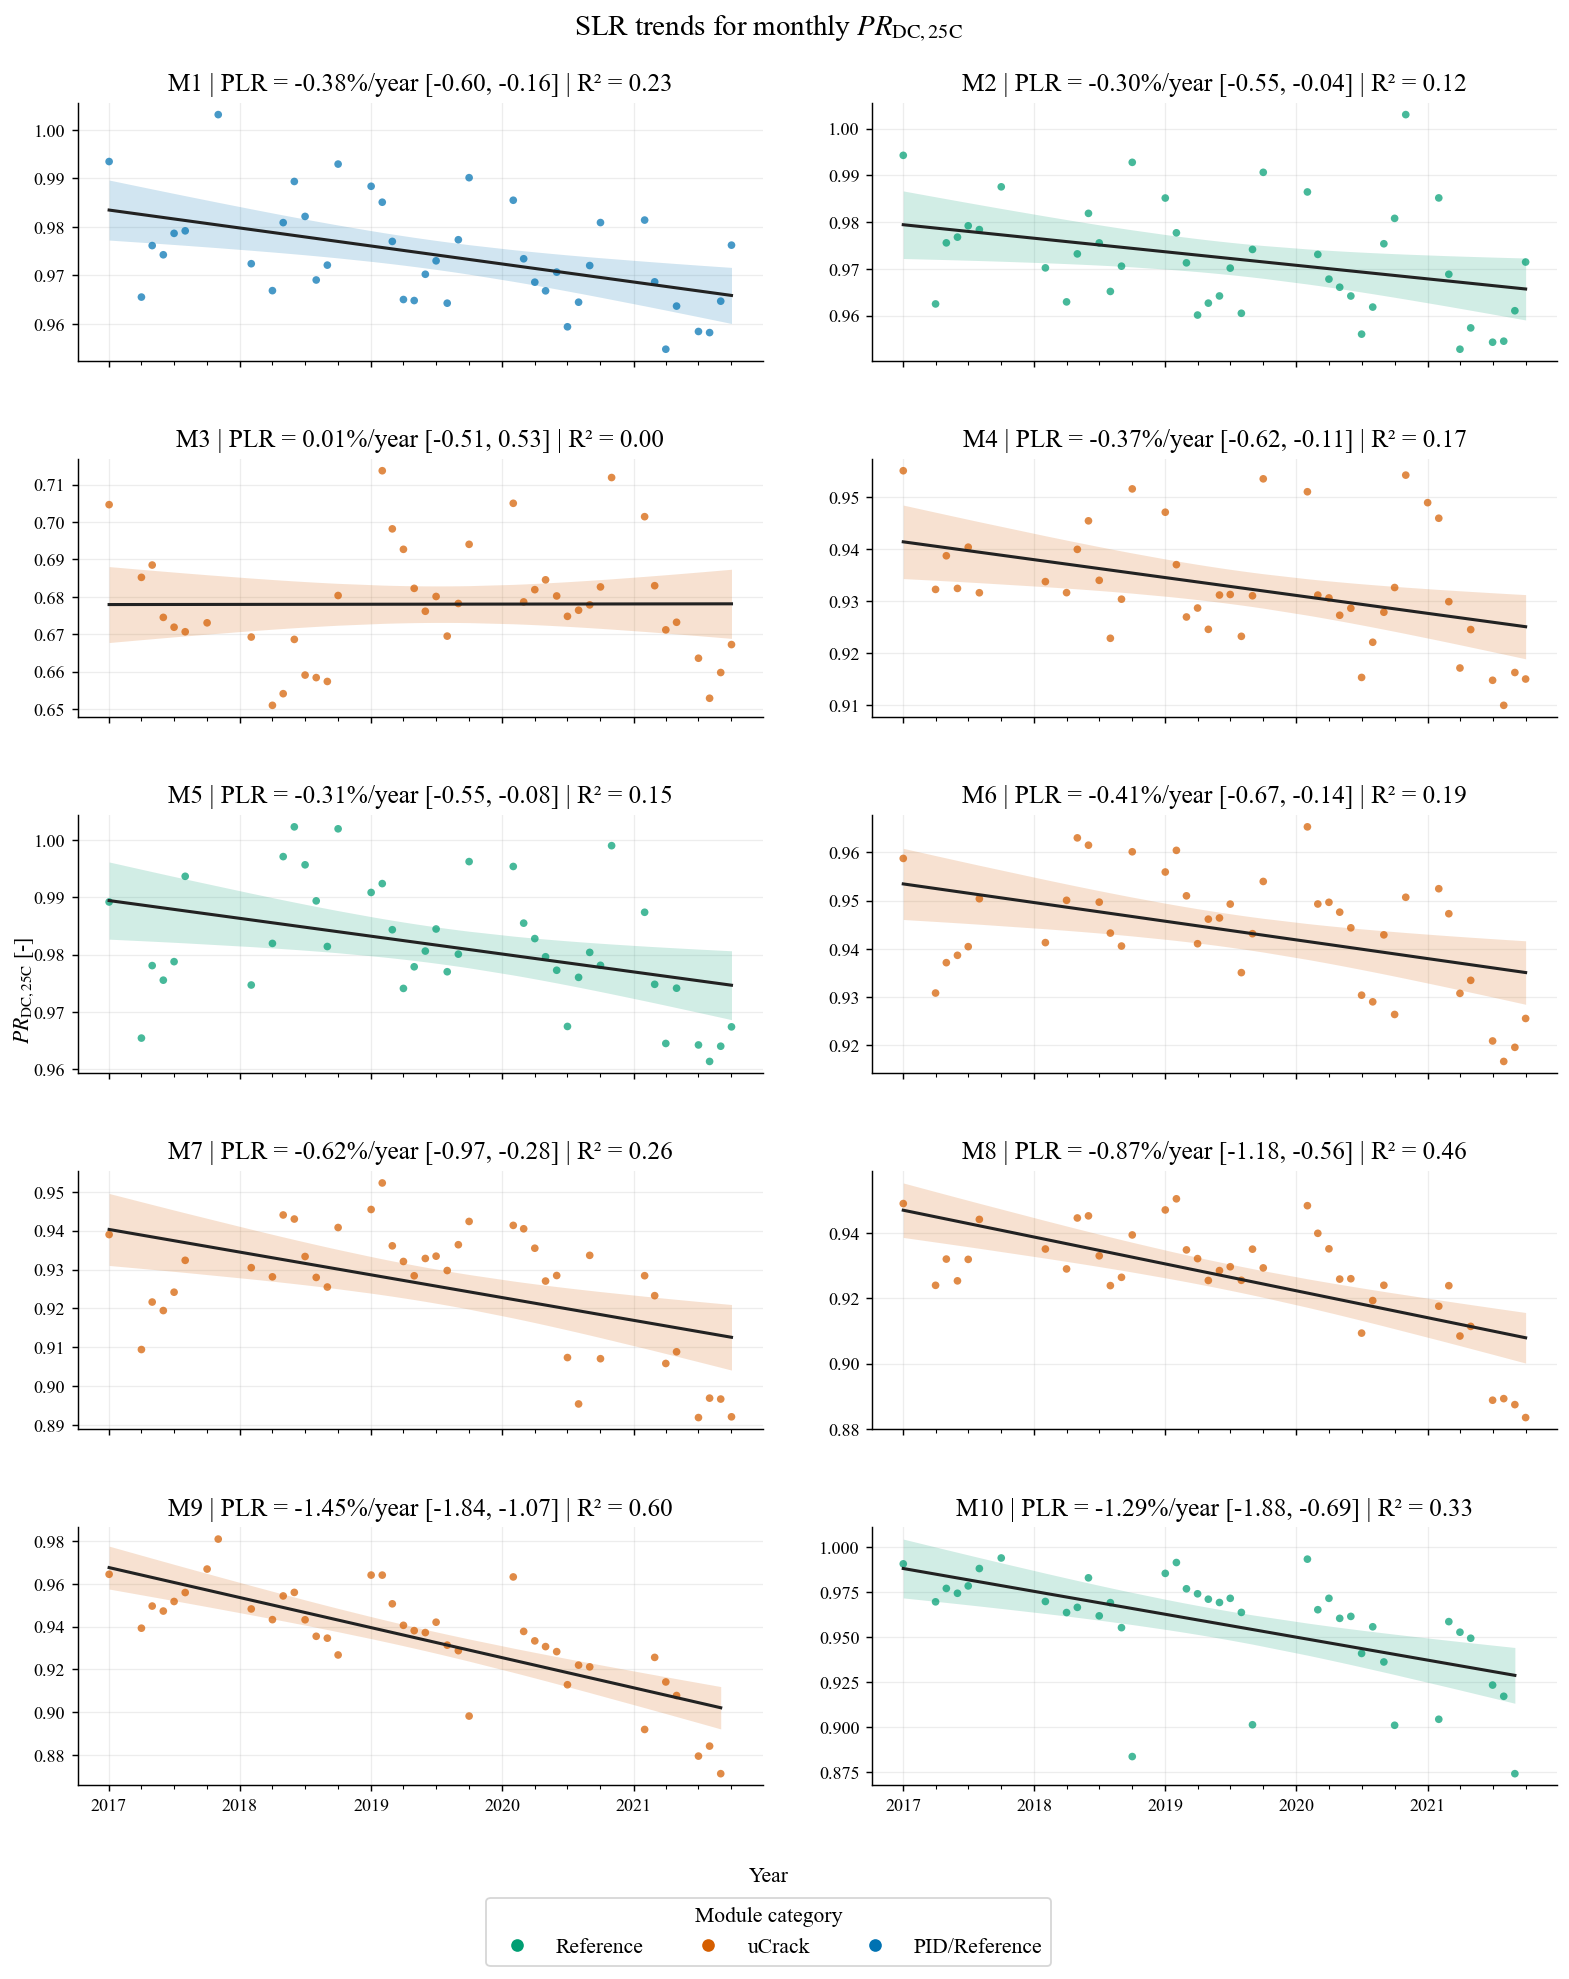

In [11]:
def plot_slr_trends_by_module(
    predictions,
    results,
    dataset_name="g200",
    save_name="slr_trends_monthly_prdc25c_g200.png",
):
    plot_pred = predictions.loc[predictions["dataset"] == dataset_name].copy()
    plot_results = results.loc[results["dataset"] == dataset_name].copy()

    fig, axes = plt.subplots(
        nrows=5,
        ncols=2,
        figsize=(12.5, 15.5),
        sharex=True,
        sharey=False,
    )

    axes = axes.flatten()

    for ax, (module_id, module_data) in zip(
        axes,
        plot_pred.groupby("Module_ID", sort=True),
    ):
        module_data = module_data.sort_values("Month_Start")

        module_type = module_data["Type"].iloc[0]
        color = get_type_color(module_type)

        result_row = plot_results.loc[
            plot_results["Module_ID"] == module_id
        ].iloc[0]

        plr = result_row["PLR_SLR_pct_per_year"]
        ci_low = result_row["PLR_SLR_ci_low_pct_per_year"]
        ci_high = result_row["PLR_SLR_ci_high_pct_per_year"]
        r2 = result_row["r_squared"]

        ax.scatter(
            module_data["Month_Start"],
            module_data[MAIN_METRIC],
            s=18,
            color=color,
            alpha=0.72,
            edgecolors="none",
            zorder=3,
        )

        ax.fill_between(
            module_data["Month_Start"],
            module_data["SLR_fit_ci_lower"],
            module_data["SLR_fit_ci_upper"],
            color=color,
            alpha=0.18,
            linewidth=0,
            zorder=2,
        )

        ax.plot(
            module_data["Month_Start"],
            module_data["SLR_fit"],
            color=BLACK,
            linewidth=1.7,
            zorder=4,
        )

        ax.set_title(
            f"M{module_id} | PLR = {plr:.2f}%/year "
            f"[{ci_low:.2f}, {ci_high:.2f}] | R² = {r2:.2f}",
            fontsize=SUBTITLE_SIZE,
            pad=7,
        )

        format_date_axis(ax)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for ax in axes[len(plot_pred["Module_ID"].unique()):]:
        ax.set_visible(False)

    fig.suptitle(
        r"SLR trends for monthly $PR_\mathrm{DC,25C}$",
        fontsize=TITLE_SIZE,
        y=0.985,
    )

    fig.supxlabel("Year", fontsize=AXIS_LABEL_SIZE, y=0.055)
    fig.supylabel(
        r"$PR_\mathrm{DC,25C}$ [-]",
        fontsize=AXIS_LABEL_SIZE,
        x=0.035,
    )

    fig.legend(
        handles=module_category_legend_handles(edgecolor="none"),
        loc="lower center",
        ncol=3,
        frameon=True,
        bbox_to_anchor=(0.5, 0.01),
        title="Module category",
        fontsize=LEGEND_SIZE,
        title_fontsize=LEGEND_SIZE,
    )

    fig.subplots_adjust(
        left=0.075,
        right=0.985,
        top=0.94,
        bottom=0.105,
        hspace=0.38,
        wspace=0.16,
    )

    save_fig(save_name, fig)
    plt.show()


plot_slr_trends_by_module(
    predictions=slr_predictions,
    results=slr_results,
    dataset_name="g200",
    save_name="slr_trends_monthly_prdc25c_g200.png",
)

## 10. Plot module-level SLR PLR estimates

This figure summarises the module-level SLR PLR estimates for the main g200 dataset. Error bars represent 95% confidence intervals.

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\slr_module_level_plr_estimates_g200.png


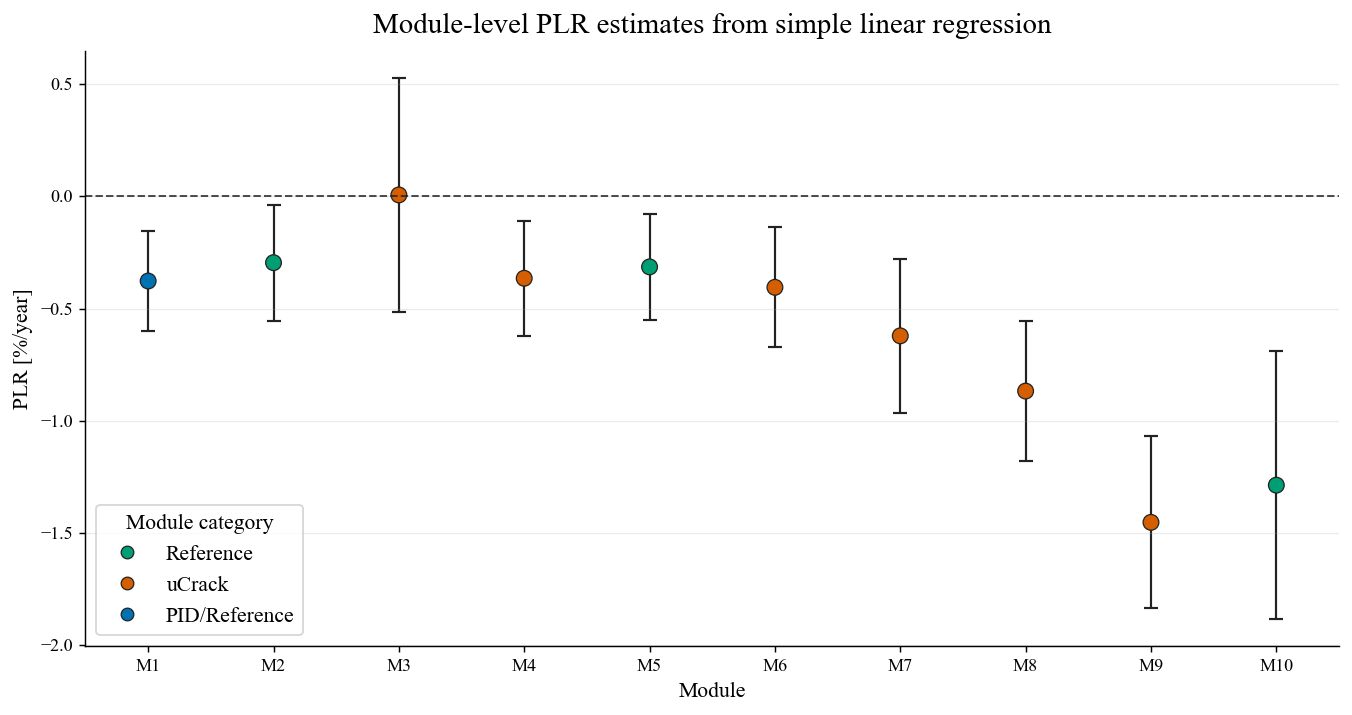

In [12]:
def plot_slr_module_level_estimates(
    results,
    dataset_name="g200",
    save_name="slr_module_level_plr_estimates_g200.png",
):
    plot_results = (
        results
        .loc[results["dataset"] == dataset_name]
        .sort_values("Module_ID")
        .copy()
    )

    plot_results["color"] = plot_results["Type"].map(TYPE_COLORS).fillna(TYPE_COLORS["Unknown"])

    x = plot_results["Module_ID"].astype(int).to_numpy()
    y = plot_results["PLR_SLR_pct_per_year"].to_numpy()

    yerr_lower = y - plot_results["PLR_SLR_ci_low_pct_per_year"].to_numpy()
    yerr_upper = plot_results["PLR_SLR_ci_high_pct_per_year"].to_numpy() - y

    fig, ax = plt.subplots(figsize=(10.5, 5.6))

    ax.errorbar(
        x,
        y,
        yerr=[yerr_lower, yerr_upper],
        fmt="none",
        ecolor=BLACK,
        elinewidth=1.2,
        capsize=4,
        capthick=1.2,
        zorder=1,
    )

    ax.scatter(
        x,
        y,
        s=76,
        c=plot_results["color"],
        edgecolor=BLACK,
        linewidth=0.7,
        zorder=2,
    )

    ax.axhline(
        0,
        color=BLACK,
        linestyle="--",
        linewidth=1.1,
        alpha=0.8,
    )

    ax.set_xlim(0.5, 10.5)
    ax.set_xticks(x)
    ax.set_xticklabels([f"M{module_id}" for module_id in x])

    ax.set_xlabel("Module", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel("PLR [%/year]", fontsize=AXIS_LABEL_SIZE)

    ax.set_title(
        "Module-level PLR estimates from simple linear regression",
        fontsize=TITLE_SIZE,
        pad=10,
    )

    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", visible=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        handles=module_category_legend_handles(edgecolor=BLACK),
        title="Module category",
        frameon=True,
        loc="lower left",
        fontsize=LEGEND_SIZE,
        title_fontsize=LEGEND_SIZE,
    )

    fig.tight_layout()

    save_fig(save_name, fig)
    plt.show()


plot_slr_module_level_estimates(
    results=slr_results,
    dataset_name="g200",
    save_name="slr_module_level_plr_estimates_g200.png",
)

## 11. Optional irradiance-filtering sensitivity figure

It compares SLR PLR estimates across the g200, g400, and sunny datasets.

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\slr_irradiance_filtering_sensitivity.png


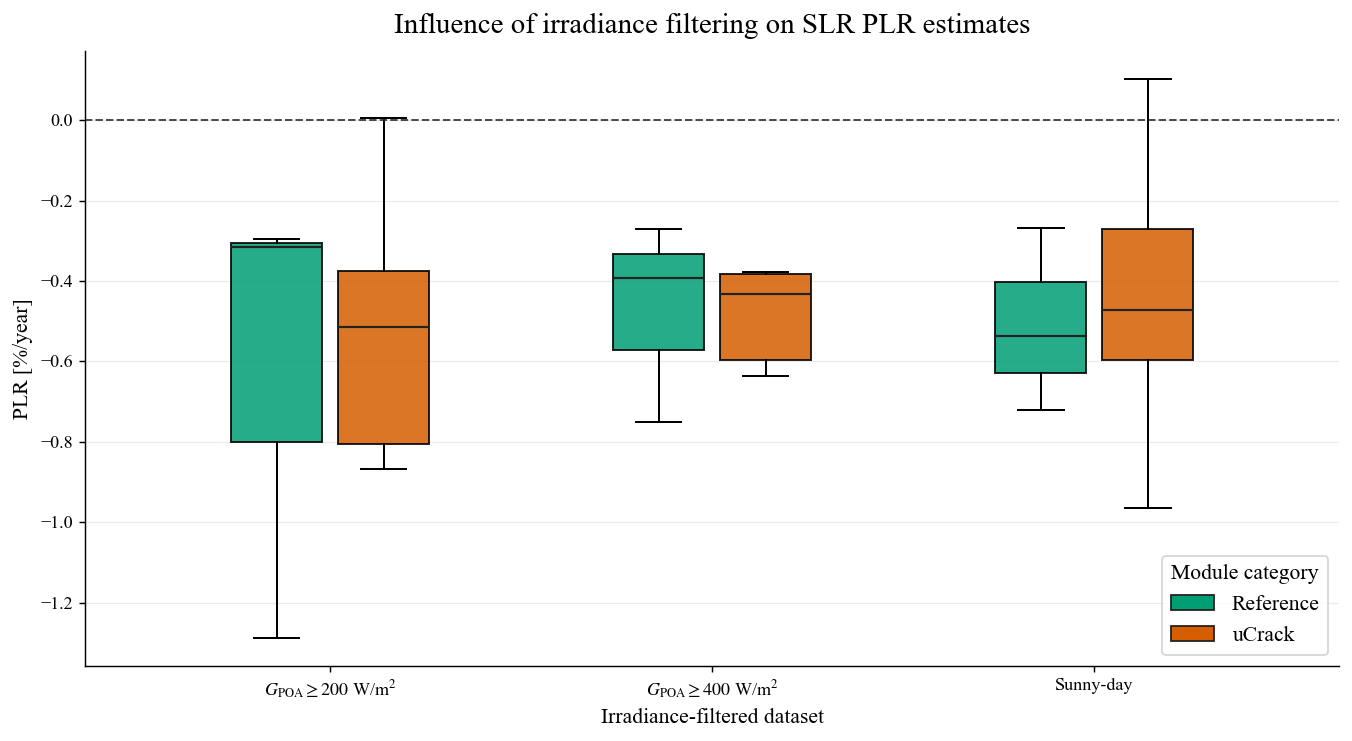

In [13]:
def plot_slr_irradiance_sensitivity(
    results,
    save_name="slr_irradiance_filtering_sensitivity.png",
):
    plot_df = results.loc[
        results["dataset"].isin(["g200", "g400", "sunny"])
    ].copy()

    # Keep reference and microcracked modules for category comparison.
    plot_df = plot_df.loc[
        plot_df["Type"].isin(["Reference", "uCrack"])
    ].copy()

    dataset_order = ["g200", "g400", "sunny"]
    type_order = ["Reference", "uCrack"]

    dataset_positions = np.arange(len(dataset_order))
    width = 0.28

    fig, ax = plt.subplots(figsize=(10.5, 5.8))

    for i, module_type in enumerate(type_order):
        offsets = dataset_positions + (i - 0.5) * width

        data_by_dataset = [
            plot_df.loc[
                (plot_df["dataset"] == dataset_name)
                & (plot_df["Type"] == module_type),
                "PLR_SLR_pct_per_year",
            ].dropna().to_numpy()
            for dataset_name in dataset_order
        ]

        bp = ax.boxplot(
            data_by_dataset,
            positions=offsets,
            widths=width * 0.85,
            patch_artist=True,
            showfliers=False,
            medianprops={"color": BLACK, "linewidth": 1.2},
            boxprops={"linewidth": 1.1},
            whiskerprops={"linewidth": 1.1},
            capprops={"linewidth": 1.1},
        )

        for box in bp["boxes"]:
            box.set_facecolor(TYPE_COLORS[module_type])
            box.set_alpha(0.85)

    ax.axhline(
        0,
        color=BLACK,
        linestyle="--",
        linewidth=1.1,
        alpha=0.8,
    )

    ax.set_xticks(dataset_positions)
    ax.set_xticklabels([DATASET_LABELS[d] for d in dataset_order])

    ax.set_xlabel("Irradiance-filtered dataset", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel("PLR [%/year]", fontsize=AXIS_LABEL_SIZE)

    ax.set_title(
        "Influence of irradiance filtering on SLR PLR estimates",
        fontsize=TITLE_SIZE,
        pad=10,
    )

    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", visible=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    sensitivity_handles = [
        Patch(
            facecolor=TYPE_COLORS["Reference"],
            edgecolor=BLACK,
            label="Reference",
        ),
        Patch(
            facecolor=TYPE_COLORS["uCrack"],
            edgecolor=BLACK,
            label="uCrack",
        ),
    ]

    ax.legend(
        handles=sensitivity_handles,
        title="Module category",
        frameon=True,
        loc="lower right",
        fontsize=LEGEND_SIZE,
        title_fontsize=LEGEND_SIZE,
    )

    fig.tight_layout()

    save_fig(save_name, fig)
    plt.show()


plot_slr_irradiance_sensitivity(
    results=slr_results,
    save_name="slr_irradiance_filtering_sensitivity.png",
)